### PROJECT TITLE
End-to-End Data Preprocessing Pipeline for Machine Learning

### Objective

To demonstrate complete understanding of all data preprocessing steps required before training any Machine Learning model.

### Step 0: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

These libraries cover data handling, visualization, and preprocessing.

### Step 1: Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving raw_data.csv to raw_data.csv


In [4]:
import pandas as pd
df = pd.read_csv('raw_data.csv')
df.head()

,Age,Gender,Salary,Purchased
0,25.0,Male,50000.0,0
1,30.0,Female,60000.0,1
2,35.0,Male,NaN,0
3,40.0,Female,80000.0,1
4,29.0,Male,52000.0,0


Always preview data first.

### Step 2: Understand the Data (EDA)

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        14 non-null     float64
 1   Gender     15 non-null     object 
 2   Salary     13 non-null     float64
 3   Purchased  15 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 612.0+ bytes


,Age,Salary,Purchased
count,14.000000,13.000000,15.000000
mean,33.857143,84153.846154,0.533333
std,8.179309,68089.213725,0.516398
min,23.000000,48000.000000,0.000000
25%,28.250000,51000.000000,0.000000
50%,32.000000,60000.000000,1.000000
75%,39.500000,80000.000000,1.000000
max,50.000000,300000.000000,1.000000


**This tells us:**

* Number of rows & columns

* Missing values

* Data types

* Statistical summary

### Step 3: Check Missing Values

In [6]:
df.isnull().sum()

,0
Age,1
Gender,0
Salary,2
Purchased,0


**Missing values must be handled before modeling.**

###  Step 4: Handle Missing Values

In [9]:
# Numerical Features – Mean Imputation
num_imputer = SimpleImputer(strategy='mean')
df[['Age', 'Salary']] = num_imputer.fit_transform(df[['Age', 'Salary']])
df

,Age,Gender,Salary,Purchased
0,25.000000,Male,50000.000000,0
1,30.000000,Female,60000.000000,1
2,35.000000,Male,84153.846154,0
3,40.000000,Female,80000.000000,1
4,29.000000,Male,52000.000000,0
5,30.000000,Female,60000.000000,1
6,45.000000,Male,120000.000000,1
7,23.000000,Female,48000.000000,0
8,50.000000,Male,300000.000000,1
9,38.000000,Female,75000.000000,1


In [30]:
# Categorical Features – Mode Imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df[['Gender']] = cat_imputer.fit_transform(df[['Gender']])
df

,Age,Gender,Salary,Purchased,Salary_per_Age
0,-1.308632,1,-1.007520,0,3.264465
1,-0.545264,0,-0.528333,1,-1.161845
2,0.218105,1,0.629085,0,0.516446
3,0.981474,0,0.430039,1,0.217030
4,-0.697937,1,-0.911682,0,-3.018189
6,1.744843,1,2.346784,1,0.854979
7,-1.613980,0,-1.103357,0,1.797057
9,0.676127,0,0.190446,1,0.113623
10,0.043621,1,-0.624171,0,-0.598082
11,0.065432,0,0.629085,1,0.590451


### Step 5: Handle Duplicate Data


In [12]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df

,Age,Gender,Salary,Purchased
0,25.000000,Male,50000.000000,0
1,30.000000,Female,60000.000000,1
2,35.000000,Male,84153.846154,0
3,40.000000,Female,80000.000000,1
4,29.000000,Male,52000.000000,0
6,45.000000,Male,120000.000000,1
7,23.000000,Female,48000.000000,0
8,50.000000,Male,300000.000000,1
9,38.000000,Female,75000.000000,1
10,33.857143,Male,58000.000000,0


Prevents biased learning.

### Step 6: Handle Outliers (IQR Method)

In [15]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Salary'] >= Q1 - 1.5 * IQR) &
        (df['Salary'] <= Q3 + 1.5 * IQR)]
df

,Age,Gender,Salary,Purchased
0,25.000000,Male,50000.000000,0
1,30.000000,Female,60000.000000,1
2,35.000000,Male,84153.846154,0
3,40.000000,Female,80000.000000,1
4,29.000000,Male,52000.000000,0
6,45.000000,Male,120000.000000,1
7,23.000000,Female,48000.000000,0
9,38.000000,Female,75000.000000,1
10,33.857143,Male,58000.000000,0
11,34.000000,Female,84153.846154,1


Outliers negatively impact model performance.

### Step 7: Encode Categorical Variables

In [16]:
# Label Encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df

,Age,Gender,Salary,Purchased
0,25.000000,1,50000.000000,0
1,30.000000,0,60000.000000,1
2,35.000000,1,84153.846154,0
3,40.000000,0,80000.000000,1
4,29.000000,1,52000.000000,0
6,45.000000,1,120000.000000,1
7,23.000000,0,48000.000000,0
9,38.000000,0,75000.000000,1
10,33.857143,1,58000.000000,0
11,34.000000,0,84153.846154,1


Converts text → numeric format.

### Step 8: Feature Scaling

In [17]:
# Standardization
scaler = StandardScaler()
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])
df

,Age,Gender,Salary,Purchased
0,-1.308632,1,-1.007520,0
1,-0.545264,0,-0.528333,1
2,0.218105,1,0.629085,0
3,0.981474,0,0.430039,1
4,-0.697937,1,-0.911682,0
6,1.744843,1,2.346784,1
7,-1.613980,0,-1.103357,0
9,0.676127,0,0.190446,1
10,0.043621,1,-0.624171,0
11,0.065432,0,0.629085,1


Required for distance-based models (KNN, SVM, NN).

### Step 9: Feature Selection

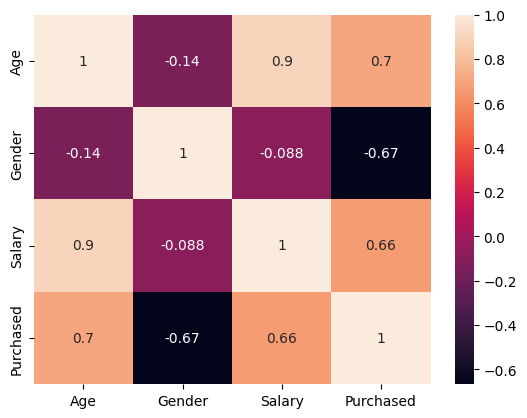

In [18]:
correlation = df.corr()
sns.heatmap(correlation, annot=True)
plt.show()

Helps remove redundant features.

### Step 10: Feature Engineering

In [19]:
df['Salary_per_Age'] = df['Salary'] / (df['Age'] + 1)
df

,Age,Gender,Salary,Purchased,Salary_per_Age
0,-1.308632,1,-1.007520,0,3.264465
1,-0.545264,0,-0.528333,1,-1.161845
2,0.218105,1,0.629085,0,0.516446
3,0.981474,0,0.430039,1,0.217030
4,-0.697937,1,-0.911682,0,-3.018189
6,1.744843,1,2.346784,1,0.854979
7,-1.613980,0,-1.103357,0,1.797057
9,0.676127,0,0.190446,1,0.113623
10,0.043621,1,-0.624171,0,-0.598082
11,0.065432,0,0.629085,1,0.590451


Creating new meaningful features improves accuracy.

### Step 11: Handle Imbalanced Data (Check)

In [20]:
df['Purchased'].value_counts()
df

,Age,Gender,Salary,Purchased,Salary_per_Age
0,-1.308632,1,-1.007520,0,3.264465
1,-0.545264,0,-0.528333,1,-1.161845
2,0.218105,1,0.629085,0,0.516446
3,0.981474,0,0.430039,1,0.217030
4,-0.697937,1,-0.911682,0,-3.018189
6,1.744843,1,2.346784,1,0.854979
7,-1.613980,0,-1.103357,0,1.797057
9,0.676127,0,0.190446,1,0.113623
10,0.043621,1,-0.624171,0,-0.598082
11,0.065432,0,0.629085,1,0.590451


If imbalance exists → SMOTE / resampling (advanced step).

### Step 12: Split Dataset

In [25]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Display the Results of the Split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9, 4)
X_test shape: (3, 4)
y_train shape: (9,)
y_test shape: (3,)


In [27]:
# Preview the Data
X_train.head()
y_train.head()

,Purchased
10,0
6,1
2,0
1,1
13,1


In [28]:
# Preview the Data
X_test.head()
y_test.head()

,Purchased
12,0
11,1
0,0


Prevents data leakage.

### Step 13: Final Validation Check

In [24]:
X_train.isnull().sum()
X_test.isnull().sum()

,0
Age,0
Gender,0
Salary,0
Salary_per_Age,0


Ensures preprocessing success.

### Final Output

* Clean dataset
* No missing values
* Encoded & scaled features
* Ready for ML models